# Machine Learning for Geoscience
### CU Boulder - Python for Geologists

You are an exploration geologist working a gold district in Saudi Arabia. You have been given access to a suite of data for the region, including a lithologic map, a stream sediment geochemical survey, and remote sensing magnetics and multispectral data. Your job: find patterns in that data that point toward buried mineralization.

Human eyes can compare two or three data layers at a time. ML can compare all of them simultaneously - and do it across the whole landscape at once.

In this session you will run three techniques on that dataset:

| Method | Type | What it does here |
|--------|------|-------------------|
| **PCA** | Unsupervised | Compresses all geochemical signatures into a handful of summary scores |
| **K-means** | Unsupervised | Groups samples by geochemical similarity |
| **Random Forest** | Supervised | Learns from known deposits to find other prospective areas |

These are not just exploration-specific tools. As you work through each section you will see notes explaining where the exact same technique appears across many other disciplines in the geosciences. The dataset is exploration-focused, but the methods can be used in so many more ways!

**How this notebook works:** Most cells are already written. Cells marked `# --- YOUR TURN ---` ask you to change one or two numbers, re-run the cell, and interpret the output. 

---
> ##### *The great part about most ML in Python is that someone else has already written the "ML" part of the code - you just have to **tune the hyperparameters** and **interpret the results**!* 
---

## Section 0: Setup
*The below code imports necessary pacakges, then defines the filepaths to input data that we will use.*

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import helpers as h

os.environ["LOKY_MAX_CPU_COUNT"] = (
    "8"  # this is a workaround for a CPU core count warning that K-means tends to throw on some OSes
)

# Data Paths
GEOCHEM_PATH = Path("data/vector/geochem.geojson")
LITHOLOGY_PATH = Path("data/vector/lithology.geojson")
OCCURRENCES_PATH = Path("data/vector/mineral occurrences.geojson")
SPECTRAL_DIR = Path("data/raster/spectral")
GEOPHYSICS_DIR = Path("data/raster/geophys")

print("Paths configured.")

Paths configured.


---
## Section 2: Look at the Data
*Before diving into analysis, it's always a good idea to take a look at your data first.*

In [2]:
# Load the datasets into the fixed analysis CRS used throughout the notebook.
geochem_gdf = gpd.read_file(GEOCHEM_PATH).to_crs(h.ANALYSIS_CRS)
vector_gdf = gpd.read_file(LITHOLOGY_PATH).to_crs(h.ANALYSIS_CRS)
targets_gdf = gpd.read_file(OCCURRENCES_PATH).to_crs(h.ANALYSIS_CRS)
tgt_proj = targets_gdf  # Set projection for later use in cross-dataset processing

# Print some basic info about the datasets
print(f"Geochem samples: {len(geochem_gdf)}")
print(f"Geochem columns: {len(geochem_gdf.columns) - 1}")  # exclude geometry column
print(f"Lithology units: {len(vector_gdf)}")
print(f"Known occurrences: {len(targets_gdf)}")
print(f"Geochem columns: {geochem_gdf.columns.tolist()}")

Geochem samples: 1243
Geochem columns: 57
Lithology units: 463
Known occurrences: 52
Geochem columns: ['SiO2_percent_xrf', 'Al2O3_percent_xrf', 'TFe2O3_percent_xrf', 'K2O_percent_xrf', 'MgO_percent_icp', 'CaO_percent_icp', 'Na2O_percent_icp', 'TC_percent_irs', 'LOI_percent_gr', 'Re_ppb_icp', 'Au_ppb_icp', 'Ir_ppb_icp', 'Os_ppb_icp', 'Pd_ppb_icp', 'Pt_ppb_icp', 'Rh_ppb_icp', 'Ru_ppb_icp', 'Br_ppm_xrf', 'Cl_ppm_xrf', 'Cr_ppm_xrf', 'Hf_ppm_xrf', 'P_ppm_xrf', 'Rb_ppm_xrf', 'Ti_ppm_xrf', 'Zr_ppm_xrf', 'Ba_ppm_icp', 'Mn_ppm_icp', 'Sr_ppm_icp', 'V_ppm_icp', 'Zn_ppm_icp', 'Be_ppm_icp', 'Bi_ppm_icp', 'Co_ppm_icp', 'Cs_ppm_icp', 'Cu_ppm_icp', 'Ga_ppm_icp', 'In_ppm_icp', 'Li_ppm_icp', 'Mo_ppm_icp', 'Nb_ppm_icp', 'Ni_ppm_icp', 'Tl_ppm_icp', 'Te_ppm_icp', 'Sc_ppm_icp', 'Y_ppm_icp', 'Ge_ppm_icp', 'I_ppm_icp', 'Ta_ppm_icp', 'W_ppm_icp', 'Sb_ppm_afs', 'Se_ppm_afs', 'Ag_ppm_es', 'B_ppm_es', 'Sn_ppm_es', 'F_ppm_ise', 'N_ppm_gc', 'S_ppm_irs', 'geometry']


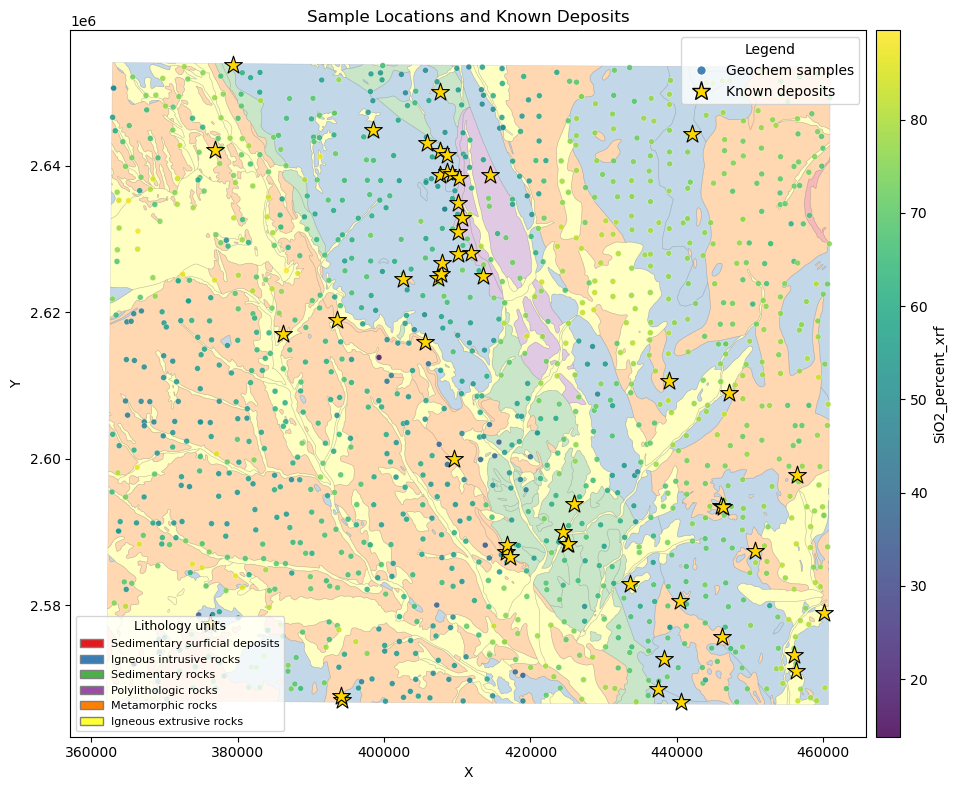

In [3]:
# Plot overview map

# Color geochem samples by a specific element (or leave as None for solid color)
OVERVIEW_GEOCHEM_COLOR_COL = "SiO2_percent_xrf"

h.plot_data_overview(
    geochem_gdf, vector_gdf, tgt_proj, geochem_color_col=OVERVIEW_GEOCHEM_COLOR_COL
)
plt.show()

**What you're looking at:**  Dots are geochemical sample sites. Gold stars are known mineral occurrences. Background polygons are mapped lithologic units.

**Interpret this map:**
1. Are sample sites evenly distributed, or do some areas have denser coverage?
2. Do any occurrences cluster in a particular lithology?
3. What does the spatial distribution of samples tell you about potential data bias?

Spatial sampling bias is a real problem in any field application - geologists tend to take measurements of interesting places, leaving "uninteresting" places quite data-barren!


> ***Note:** A major part of ML work is data preparation; removing non-numeric columns from geochem datasets, imputing missing values, ensuring projections align, and many more. This has already been done for the sake of this exercise, but makes up the majority of "ML work" in the geosciences!*



---
## Section 3: PCA - Compressing 57 Elements Into Something Useful

### What is PCA?

In our geochem dataset, many elements move together. Cu, Mo, and Au often co-vary in mineralized systems. As, Sb, and Hg can co-vary along hydrothermal pathways. Fe and Mn track weathering. PCA finds those co-varying groups and replaces them with new summary variables called **principal components**.

Instead of 57 maps - one per element - you get a handful of summary maps that together capture most of the geochemical information. PC1 captures the dominant pattern in the dataset; PC2 captures the next largest independent pattern; and so on.

> **What is explained variance?** Each PC explains some fraction of the total spread in the data. If PC1 explains 40% of variance, then 40% of all geochemical variation across the study area is described by that single new axis.

**Basic PCA workflow in this notebook:**
1. Build a matrix of geochemical variables
2. Fit the PCA model
3. Check explained variance
4. Inspect loadings to see which elements drive each PC
5. Map the PC scores to see where those patterns occur

---

> **The same idea in other fields:**
> - *Stratigraphy:* PCA of drill core geochemistry collapses the data into 2–3 scores that reveal chemostratigraphic packages - useful when the visual lithology is uniform
> - *Petrology:* Major element PCA of volcanic rocks automatically recovers chemically distinct groups
> - *Environmental:* PCA of water chemistry can reduce many measurements to two main trends, making it easier to see the biggest differences between sampling sites
> - *Petroleum:* PCA of a few common well logs can combine them into one simpler summary curve that highlights broad lithology changes

In [4]:
# Step 1: build the PCA input matrix

pca_inputs = h.prepare_pca_inputs(geochem_gdf)

# This is the scaled numeric matrix for PCA
X_scaled = pca_inputs["X_scaled"]

# This is the list of element names corresponding to the columns in X_scaled
pca_cols = pca_inputs["pca_cols"]

print(f"PCA input matrix: {X_scaled.shape[0]} samples x {X_scaled.shape[1]} variables")

Original dimensions: 57
PCA input matrix: 1243 samples x 57 variables


In [5]:
# Step 2: fit PCA with scikit-learn
from sklearn.decomposition import PCA

# Keep all components so we can inspect the full variance curve.
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f"Input dimensions : {X_scaled.shape[1]} elements")
print(f"Output dimensions: {X_pca.shape[1]} principal components")
print(f"Shape of PCA scores: {X_pca.shape}  (one row per sample)")

Input dimensions : 57 elements
Output dimensions: 57 principal components
Shape of PCA scores: (1243, 57)  (one row per sample)


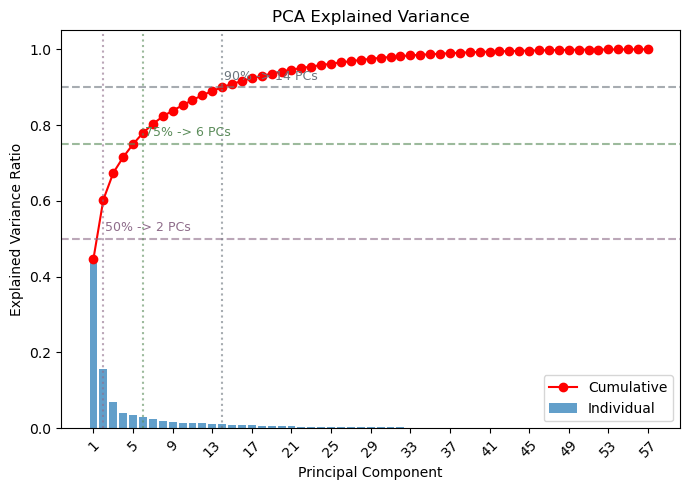

In [6]:
# Step 3: inspect explained variance
fig, ax = h.plot_pca_variance(pca)
plt.show()

**What you're looking at:** Each bar is one principal component. The red line shows cumulative variance. The dashed lines mark 50%, 75%, and 90% thresholds.

**Interpret this plot:**
1. How much variance does PC1 explain?
2. How many PCs do you need to reach 75% of total variance? 
3. Where is the "elbow" - the point where adding another PC stops helping much? 
4. Based on this plot, how many PCs would you carry forward for interpretation?

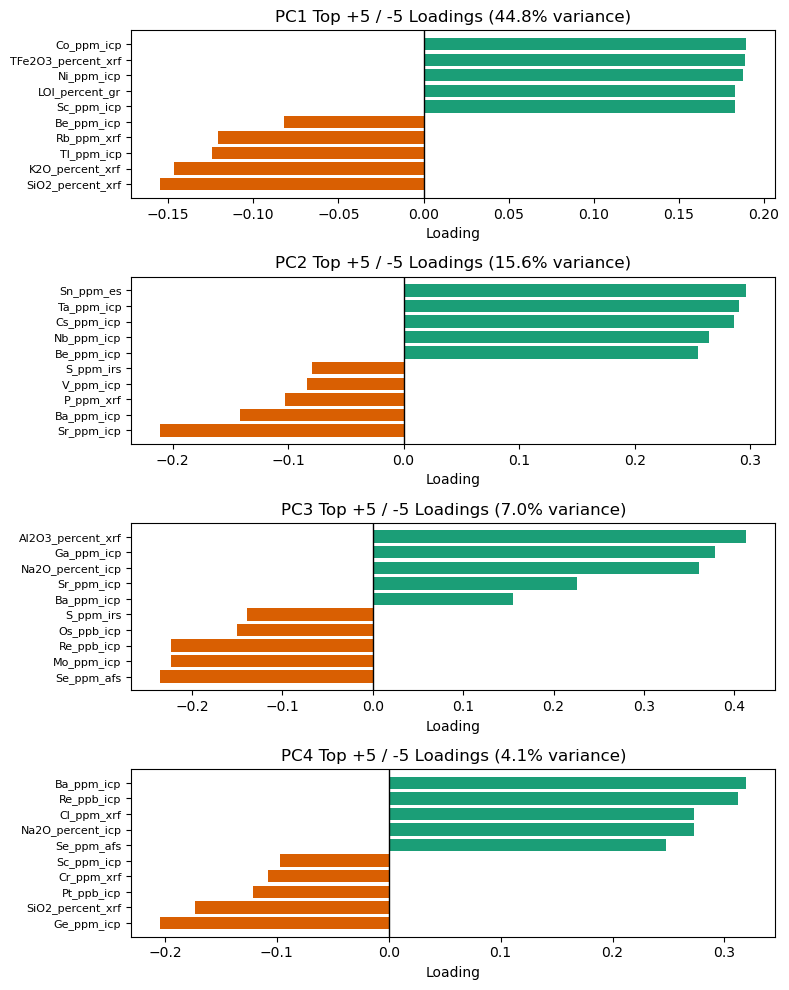

In [7]:
# Step 4: inspect loadings for the first 4 components

fig, axes = h.plot_pca_loadings(pca, pca_cols, n_components=4)
plt.show()

**What you're looking at:** Each subplot shows one PC. Green bars load positively; orange bars load negatively. Bar length shows how strongly that element contributes.

**Interpret these loadings:**
1. What element has the strongest positive loading on PC1? 
2. What variable has the strongest negative loading on PC1? 
3. PC1 appears to contrast signatures like SiO2 and K2O with Fe2O3, Co, and Ni... what broad mineralogical attribute might this represent?
4. What about PC2, which contrasts elements like Sn, Ta, Cs, and Nb against Sr, Ba, and P?

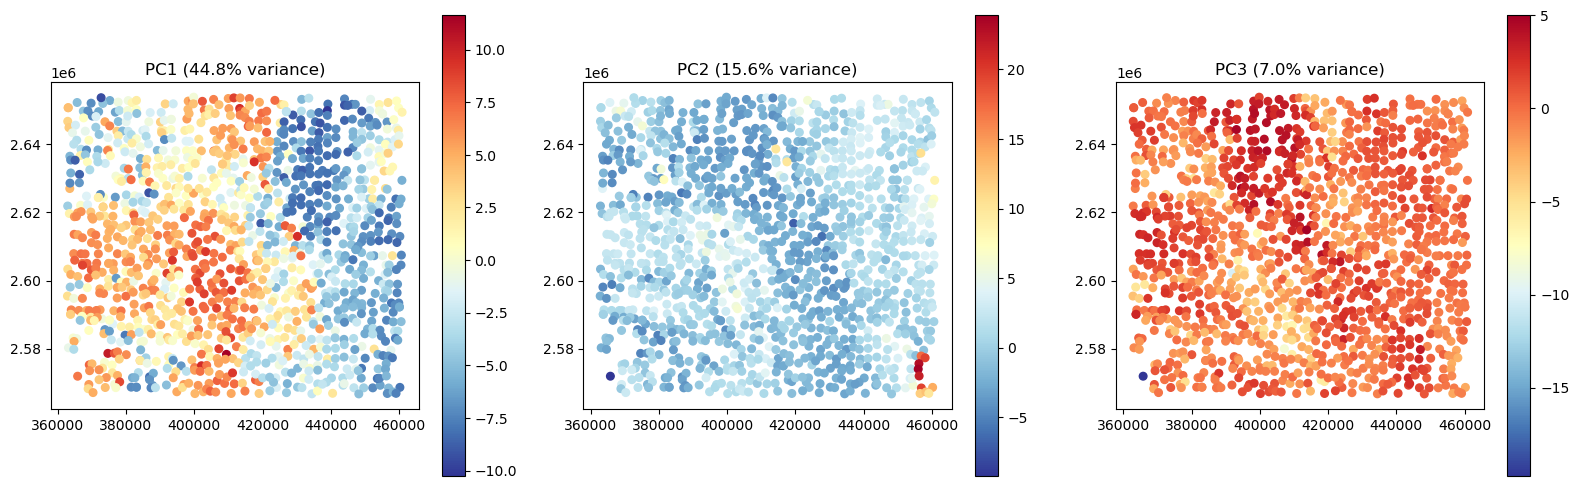

In [8]:
# Step 5: map the first 3 PCA scores in geographic space

fig, axes = h.plot_spatial_pca_components(geochem_gdf, X_pca, pca, n_components=3)
plt.show()

**What you're looking at:** Each map shows the PC score at each sample location. Warm = high; cool = low. Compare these to the lithology map from Section 2.

**Interpret these maps:**
1. Does PC1 vary smoothly across the study area, or does it show sharp boundaries?
2. Do PC score boundaries correspond to lithology contacts? What would that mean?
3. Do any known deposit locations appear in high or low PC score zones?
4. If this were a chemostratigraphy dataset (core samples down a section instead of points across a map), what would each map represent?

---
## Section 4: K-means - Finding Geochemical Populations

### What is K-means?

PCA compressed our 57 elements into summary scores. K-means takes the next step: it partitions every sample into one of *k* discrete groups based on similarity across all variables at once.

In an exploration context, those groups might represent distinct geochemical populations - background granites, altered zones, mineralized samples. But we don't tell the algorithm that. It finds the groupings from the data alone, and then we interpret them geologically.

Unlike PCA, K-means gives each sample a **label** (Cluster 0, Cluster 1, ...) that can be plotted directly on a map and compared against lithology, structure, or deposit locations.

**The challenge:** you have to choose *k* before running. We will use two diagnostics to help:
- **Elbow plot:** how much does within-cluster variance decrease as k increases? Look for the bend.
- **Silhouette score:** how cleanly separated are the clusters? Higher is better (max = 1). Also look for local maxima.

---

> **The same idea in other fields:**
> - *Petroleum geology:* K-means on a few common well logs can split a well into recurring electrofacies groups
> - *Stratigraphy:* K-means on core chemistry can divide a section into intervals with similar geochemical character
> - *Provenance:* K-means on grain chemistry can group samples that likely came from similar source regions
> - *Environmental:* K-means on water chemistry can group sites with similar chemical signatures

---

> ***Note:** There is no single correct k. Two geologists might reasonably choose different values and both be right - the goal is geological interpretability, not metric optimization.*

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Run diagnostics for k = 2 through k = 8
K_RANGE = range(2, 9)
inertias = []
silhouettes = []

print("Running K-means diagnostics for k =", list(K_RANGE), "...")
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
print("Done.")

Running K-means diagnostics for k = [2, 3, 4, 5, 6, 7, 8] ...
Done.


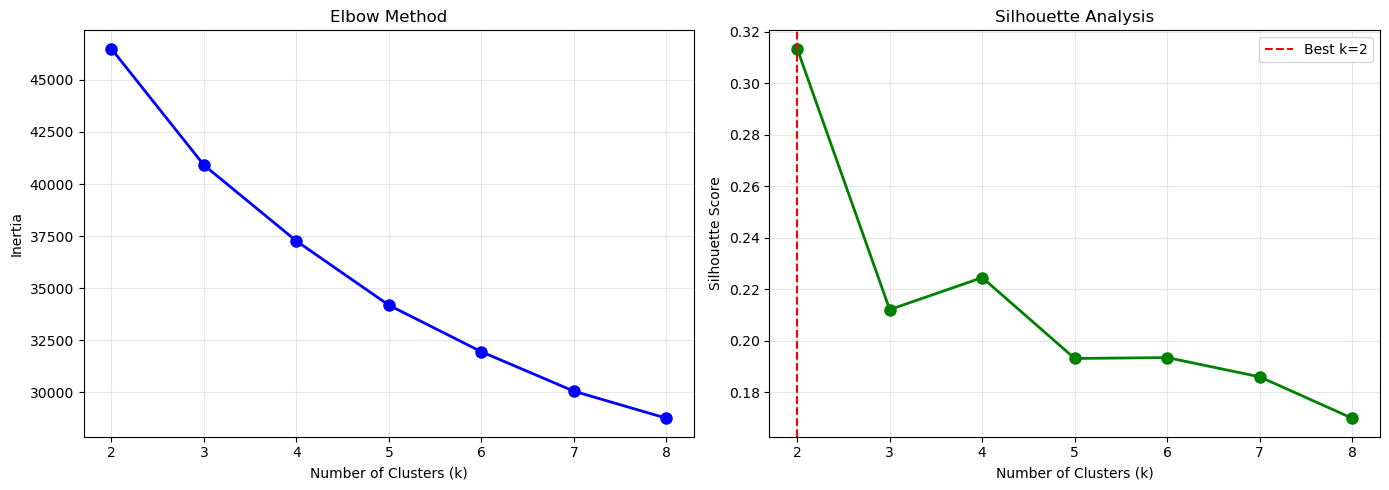

In [10]:
# Elbow and silhouette plots
fig, axes = h.plot_elbow_silhouette(list(K_RANGE), inertias, silhouettes)
plt.show()

**What you're looking at:** Left = elbow plot (lower inertia = tighter clusters). Right = silhouette scores (higher = more distinct clusters; 0.2–0.5 is typical for real geochemical data). In many real geochemical datasets, silhouette is highest at k = 2 and then drops as you ask the algorithm to split the data into more detailed groups.

**Interpret these plots:**
1. On the inertia curve, around what k does the rate of improvement start to slow down? 
2. Which k gives the highest silhouette score? 
3. If silhouette prefers k = 2 but the elbow suggests you could justify k = 3 or 4, what is the tradeoff between those choices? 
4. Geologically, what might k = 2 capture, and what extra detail might you gain by moving to k = 3 or 4? 


In [11]:
# --- YOUR TURN ---
# Choose the number of clusters based on the plots above.
#
MY_K = 4  # Try: 3, 4, or 5

chosen_k = MY_K
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
print(
    f"k = {chosen_k} | cluster sizes: { {k: int((cluster_labels==k).sum()) for k in range(chosen_k)} }"
)

k = 4 | cluster sizes: {0: 393, 1: 360, 2: 480, 3: 10}


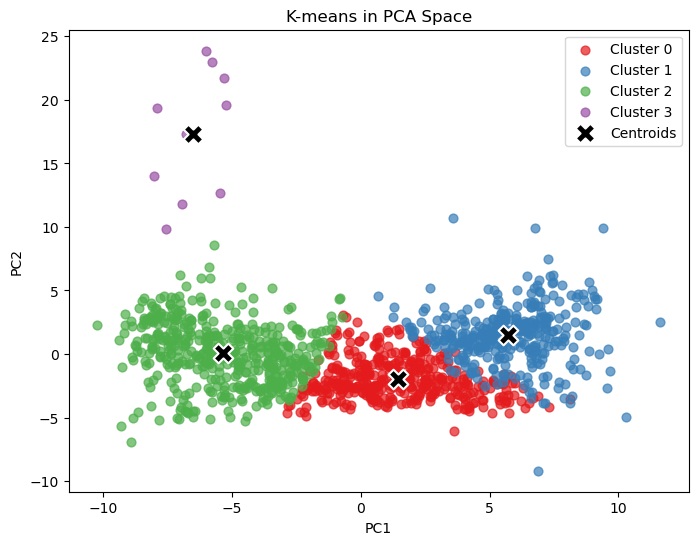

In [12]:
# PCA scatter colored by cluster - do the groups separate cleanly in PC space?
fig, ax = h.plot_kmeans_pca_scatter(X_pca, cluster_labels)
plt.show()

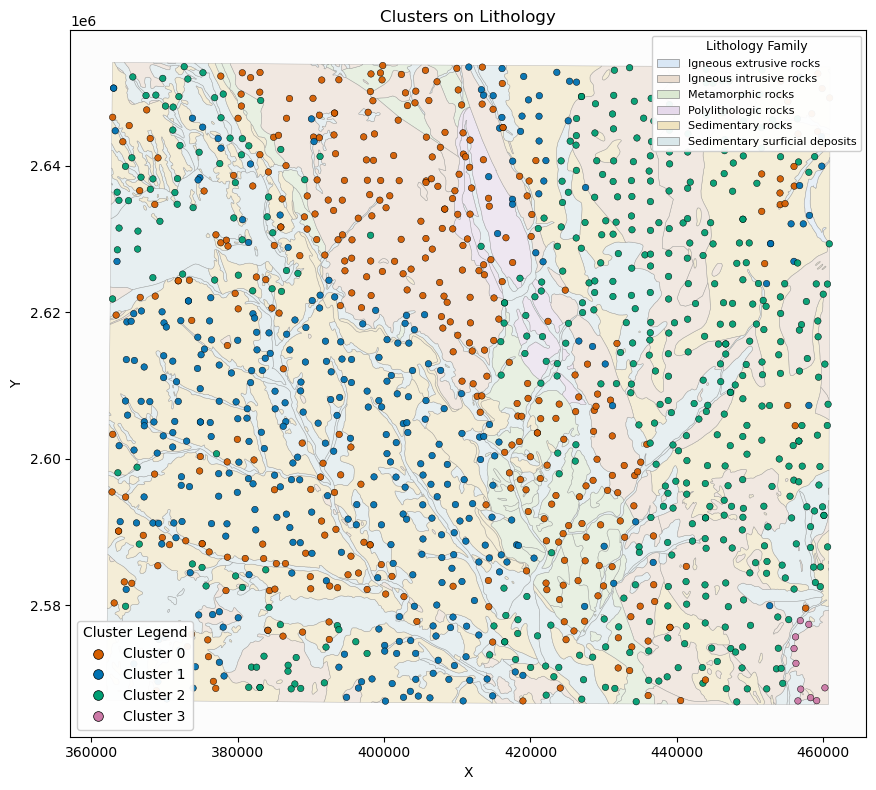

In [ ]:
# Geographic overlay - do clusters follow lithology contacts?
# Choose which lithology field to display in the background.
LITH_DISPLAY_COL = "lithology_family"
# Options: "lithology_family", "main_lithology", "geological_era", "tectonic_setting"

fig, ax = h.plot_clusters_on_lithology(
    vector_gdf, geochem_gdf, cluster_labels, lith_column=LITH_DISPLAY_COL
)
plt.show()

**What you're looking at:** Clusters overlaid on lithology polygons. If clusters align with lithology contacts, the element patterns are controlled by source rock composition. If they cut across contacts, something else is driving them - possibly hydrothermal alteration, or a transported signal.

**Interpret these maps:**
1. Do any clusters follow lithology contact lines? 
2. Are any clusters scattered across multiple lithologies? What might that indicate?
3. Try inspecting different `LITH_DISPLAY_COL` options to see if the clusters align better with one than another.
4. Try a different `MY_K`. Do the same groupings persist at different k, or do boundaries shift dramatically?

---
## Section 5: Supervised ML - Predicting Mineral Prospectivity

### From patterns to predictions

PCA and K-means found structure in the data without any labels. Now we give the algorithm something specific to learn: **known mineral occurrences**.

We label each sample location as:
- **1 (positive)** - within 500 m of a known deposit
- **0 (background)** - everything else

Then we train a **Random Forest**: an ensemble of decision trees whose predictions are combined into one final probability. Each tree votes on whether a new sample looks deposit-like. The output is a probability from 0 to 1.

```
Raster + lith + geochem  ──►  Feature matrix  ──►  Random Forest  ──►  Probability score
(sampled at points)         (standardized)       (100 trees)         (0 = background, 1 = deposit-like)
```

**Features for this section:** We combine raster predictors sampled at each point with lithology and geochemistry features. That means the model sees spectral remote sensing, geophysics, mapped lithology, and the geochemical assays together.
To reduce spatial autocorrelation leakage, train/test evaluation uses a checkerboard split in projected space instead of a random split.

> **Instructor note:** The training targets are still the known mineral occurrences, but the predictor stack now combines raster, lithology, and geochemistry inputs at each sample location.

In [ ]:
# SECTION 5: SUPERVISED ML

# --- YOUR TURN ---
# Set all parameters here before running the cells below.

# RADIUS_M: how close must a sample be to a known deposit to count as "positive"?
# Smaller radius = fewer positives, harder problem. Larger = more signal, easier, less geologically sound.
RADIUS_M = 5000  # options: 1000 (tight)  |  2000 (moderate)  |  5000 (generous)
# RADIUS_M = 1000
# RADIUS_M = 2000

# N_ESTIMATORS: number of decision trees. More = slower but often more stable.
N_ESTIMATORS = 100  # options: 50 (fast)  |  100 (balanced)  |  200 (thorough)
# N_ESTIMATORS = 50
# N_ESTIMATORS = 200

# MAX_DEPTH: how deep each tree can grow. None = unlimited.
MAX_DEPTH = None  # options: None (full depth)  |  5 (shallow)  |  10 (medium)
# MAX_DEPTH = 5
# MAX_DEPTH = 10

# CHECKER_SIZE_M: spatial checkerboard cell size for train/test split (meters)
CHECKER_SIZE_M = 10000  # options: 2500 | 5000 | 10000

print(
    f"radius={RADIUS_M} m | trees={N_ESTIMATORS} | max_depth={MAX_DEPTH} | checker={CHECKER_SIZE_M} m"
)

In [ ]:
# ── Step 1: Extract features and labels ───────────────────────────────────
X_raw, predictor_names = h.extract_raster_values(
    geochem_gdf, SPECTRAL_DIR, GEOPHYSICS_DIR
)
lith_features = h.add_lithology_features(geochem_gdf, vector_gdf)
geochem_cols = h.get_geochem_columns(geochem_gdf)
geochem_X = np.log1p(geochem_gdf[geochem_cols].values.astype(float))
geochem_names = [f"geochem_{c}" for c in geochem_cols]
y = h.prepare_ml_labels(geochem_gdf, targets_gdf, radius_m=RADIUS_M)

print(
    f"Positive: {y.sum()} ({100*y.mean():.1f}%) | Background: {(~y.astype(bool)).sum()}"
)

h.plot_feature_overview(
    geochem_gdf,
    SPECTRAL_DIR,
    GEOPHYSICS_DIR,
    vector_gdf,
    y,
    RADIUS_M,
    tgt_proj,
    geochem_X,
    geochem_cols,
)
plt.show()

In [ ]:
# ── Step 2: Build feature matrix ──────────────────────────────────────────
# Drop rows where any predictor value is missing
valid = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(geochem_X).any(axis=1)

# Combine: rasters + one-hot lithology + log-transformed geochem
X_combined = np.hstack([X_raw[valid], lith_features.values[valid], geochem_X[valid]])
all_predictor_names = predictor_names + list(lith_features.columns) + geochem_names

y_valid = y[valid]
gdf_valid = geochem_gdf.iloc[valid].reset_index(drop=True)

# Standardize so all features contribute equally regardless of value range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_combined)

print(f"Feature matrix: {X.shape[0]} samples × {X.shape[1]} predictors")
print(
    f"  {len(predictor_names)} rasters | {len(lith_features.columns)} lithology | {len(geochem_names)} geochem"
)

In [ ]:
# ── Step 3: Split, train, and evaluate ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

split = h.spatial_checkerboard_split(gdf_valid, y=y_valid, cell_size_m=CHECKER_SIZE_M)
X_train, X_test = X[split["train_mask"]], X[split["test_mask"]]
y_train, y_test = y_valid[split["train_mask"]], y_valid[split["test_mask"]]
print(
    f"Train: {len(X_train)} ({int(y_train.sum())} pos) | Test: {len(X_test)} ({int(y_test.sum())} pos)"
)

h.plot_spatial_split(gdf_valid, split, vector_gdf, tgt_gdf=tgt_proj)
plt.show()

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    class_weight="balanced",
    random_state=42,
)
rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:, 1]

importance_df = h.get_feature_importance(rf, all_predictor_names)
h.plot_roc_pr_curves(y_test, y_prob)
plt.show()

In [ ]:
# ── Predicted probability map ─────────────────────────────────────────────
y_prob_all = rf.predict_proba(X)[:, 1]
h.plot_probability_map(gdf_valid, y_valid, y_prob_all, vector_gdf, tgt_proj, RADIUS_M)
plt.show()

**What you're looking at:** Left = the labels the model was trained on. Right = the model's predicted probability for every sample, colored from low (dark purple) to high (bright yellow).

**Interpret this map:**
1. Do high-probability zones (yellow) overlap with the gold stars?
2. Are there high-probability areas with no known deposits? Could those be missed deposits, or false alarms?
3. Change `RADIUS_M` and re-run. How does the probability map change when you make the positive zone larger or smaller?
4. Compare the right map to the cluster map from Section 4. Do any K-means clusters align with high-probability zones?

**What you're looking at:** The ROC curve shows the trade-off between catching real deposits (True Positive Rate) and generating false alarms (False Positive Rate). The area under the curve (AUC) is the headline number.

**Interpret these curves:**
1. What is the AUC of your model? _____
2. AUC = 0.5 means _____ . AUC = 1.0 means _____.
3. Try `RADIUS_M = 1000` vs `5000`. How does a tighter labeling radius affect AUC? Why?
4. Try `N_ESTIMATORS = 50` vs `200`. Does AUC change meaningfully?

> **Instructor note:** AUC will usually drop relative to a random split, because the checkerboard evaluation is stricter and reduces spatial leakage.

In [ ]:
# --- YOUR TURN ---
# How many top predictor layers do you want to display?
TOP_N = 20  # Try: 3, 5, or all (set to len(predictor_names))

fig, ax = h.plot_feature_importance(importance_df, top_n=TOP_N)
plt.show()

**What you're looking at:** Which raster predictor layers drove the model's decisions. Longer bar = more important.

**Interpret this chart:**
1. What is the most important predictor layer? _____
2. Are spectral alteration indices near the top, or are geophysics layers carrying more signal?
3. If you set `MAX_DEPTH = 5`, does the importance ranking change?
4. Try a different `RADIUS_M`. Do the same layers stay on top?

---
## Section 6: Wrap-Up

### What you covered today

| Section | Method | Type | What it produced |
|---------|--------|------|------------------|
| 3 | PCA | Unsupervised | Summary geochemical components; element association patterns |
| 4 | K-means | Unsupervised | Discrete geochemical populations mapped against lithology |
| 5 | Random Forest | Supervised | Deposit probability score at each sample location |

### The exploration geologist's toolkit - and everyone else's

You ran all three techniques on a Saudi Arabia gold dataset, but none of them know they're doing exploration. Swap the input data and the interpretation changes; the code does not.

| Your data | PCA gives you | K-means gives you | Supervised ML gives you |
|-----------|--------------|-------------------|------------------------|
| Well log suite | Composite curves, noise-reduced | Electrofacies without core | Reservoir quality prediction |
| Core geochemistry | Chemostratigraphic axes | Unit boundaries, objective picks | Lithology prediction at unsampled depths |
| Groundwater chemistry | Source fingerprints | Contamination populations | Risk scores at unmonitored wells |
| Satellite multispectral | Spectral end-members | Land cover / alteration classes | Hazard or resource probability maps |

### How the full exploration pipeline works

The notebook trained on point data - one row per sample location. In production:
- Geochem, spectral, and geophysical rasters are all combined as input features
- A spatial cross-validation scheme prevents the model from memorising deposit locations instead of learning the underlying signal
- Multiple independent model runs are stacked - the final map is a consensus probability
- Uncertainty is quantified alongside the probability score and delivered to the client

The core ML is what you ran today. The complexity is in the data pipeline around it.

### Topics to explore next

- **Anomaly detection** with Isolation Forest - flags unusual samples without any deposit labels
- **Positive-unlabeled learning** - formally handles the fact that "background" ≠ "confirmed absence of deposit"
- **Spatial cross-validation** - why random train/test split over-estimates model performance for spatially correlated data
- **UMAP / t-SNE** - non-linear dimensionality reduction for datasets where PCA misses curved structure